# 2 — Modelling

Predicting fuel consumption per intervention, evaluated against explicit
baselines. The objective, set in notebook 1, is retrospective anomaly
detection: given what the tractor actually did, how much fuel *should* the job
have taken?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys, os

from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import KFold, cross_val_score, train_test_split

sys.path.append("../src")

PROCESSED = "../data/processed"
FIGURES = "../reports/figures"
os.makedirs(FIGURES, exist_ok=True)
plt.style.use("seaborn-v0_8-whitegrid")

RANDOM_STATE = 42
TARGET = "Consommation (L)"

## 1. Features and target

In [2]:
df = pd.read_csv(f"{PROCESSED}/merged_data.csv")

# Identifiers and free-text equipment labels are dropped; Operation is the one
# categorical with few enough levels to one-hot encode usefully.
DROP = ["ID", "Debut", "Fin", "Machine", "Outil", "Parcelle"]
model_df = pd.get_dummies(df.drop(columns=DROP), columns=["Operation"], drop_first=True)

X = model_df.drop(columns=[TARGET])
y = model_df[TARGET]

print(f"{X.shape[0]} rows, {X.shape[1]} features")
print(list(X.columns))

500 rows, 15 features
['Puissance', 'Largeur', 'Duree_mn', 'Distance_km', 'Vitesse_moy_kmph', 'Vitesse_med_kmph', 'Vitesse_max_kmph', 'Accélération_moy_kmph2', 'Accélération_max_kmph2', 'Surface_ha', 'Perimetre_km', 'Complexite', 'Operation_Semis', 'Operation_Traitements phytosanitaires', 'Operation_Travaux du sol']


## 2. One holdout set, touched once

The holdout is split off now and not looked at again until section 5. All model
selection happens by cross-validation on the training portion, so the holdout
score stays an honest estimate.

In [3]:
X_train, X_holdout, y_train, y_holdout = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f"train: {len(X_train)}   holdout: {len(X_holdout)}")

train: 400   holdout: 100


## 3. Baselines first

A mean absolute error of "0.54 litres" means nothing on its own. The target has
a median of 1.14 L, so the question is always: better than *what*?

Four reference points, each scored by 5-fold cross-validation on the training
set only.

In [4]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

candidates = {
    "Predict the median": DummyRegressor(strategy="median"),
    "Linear, duration only": LinearRegression(),   # fitted on Duree_mn alone
    "Linear, all features": LinearRegression(),
    "Gradient boosting (defaults)": GradientBoostingRegressor(random_state=RANDOM_STATE),
    "Gradient boosting (hand-tuned)": GradientBoostingRegressor(
        n_estimators=100, min_samples_split=3, max_features="sqrt",
        max_depth=10, random_state=RANDOM_STATE),
}

rows = []
for name, model in candidates.items():
    data = X_train[["Duree_mn"]] if name == "Linear, duration only" else X_train
    scores = -cross_val_score(model, data, y_train, cv=cv,
                              scoring="neg_mean_absolute_error")
    rows.append({"model": name, "MAE": scores.mean(), "std": scores.std()})

results = pd.DataFrame(rows).sort_values("MAE", ascending=False).reset_index(drop=True)
results["vs baseline"] = results["MAE"].iloc[0] / results["MAE"]
print(results.to_string(index=False, float_format=lambda v: f"{v:.3f}"))

                         model   MAE   std  vs baseline
            Predict the median 3.135 0.543        1.000
         Linear, duration only 0.835 0.096        3.754
          Linear, all features 0.619 0.055        5.067
Gradient boosting (hand-tuned) 0.537 0.113        5.833
  Gradient boosting (defaults) 0.421 0.052        7.438


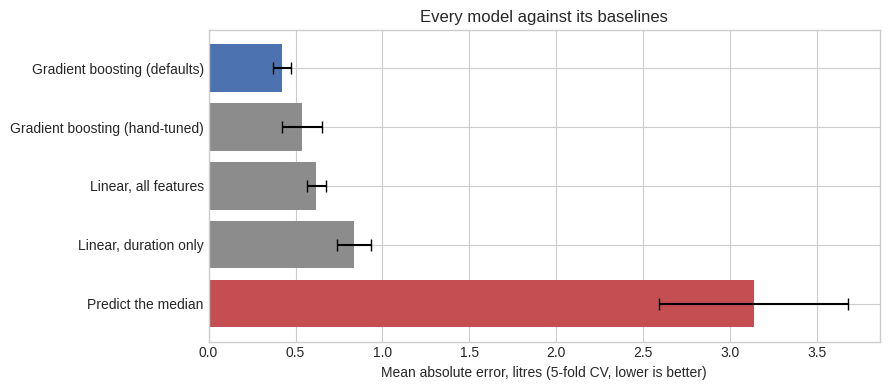

In [5]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(results["model"], results["MAE"], xerr=results["std"],
        color=["#C44E52"] + ["#8C8C8C"] * (len(results) - 2) + ["#4C72B0"],
        capsize=4)
ax.set_xlabel("Mean absolute error, litres (5-fold CV, lower is better)")
ax.set_title("Every model against its baselines")
plt.tight_layout()
plt.savefig(f"{FIGURES}/model_comparison.png", dpi=120, bbox_inches="tight")
plt.show()

## 4. Does the hand-tuning help?

The hand-tuned configuration sets `max_depth=10` on 400 training rows. Fitting
it and scoring on its own training data shows what that depth buys.

In [6]:
tuned = GradientBoostingRegressor(n_estimators=100, min_samples_split=3,
                                  max_features="sqrt", max_depth=10,
                                  random_state=RANDOM_STATE).fit(X_train, y_train)
default = GradientBoostingRegressor(random_state=RANDOM_STATE).fit(X_train, y_train)

for name, model in [("hand-tuned", tuned), ("defaults", default)]:
    train_mae = mean_absolute_error(y_train, model.predict(X_train))
    cv_mae = -cross_val_score(model, X_train, y_train, cv=cv,
                              scoring="neg_mean_absolute_error").mean()
    print(f"{name:12s}  train MAE {train_mae:7.4f}   cross-validated MAE {cv_mae:.4f}")

hand-tuned    train MAE  0.0002   cross-validated MAE 0.5374


defaults      train MAE  0.1638   cross-validated MAE 0.4215


The hand-tuned model reaches a training error of essentially zero: at depth 10
it memorises the training set. Cross-validation shows it generalises no better
than the untuned model, so the deeper trees are pure variance. **The defaults
win, and they are what the final model uses.**

A proper hyperparameter search would be the next improvement; inventing
parameters by hand is worse than not touching them.

## 5. Final evaluation on the holdout

Fit on the training set only, scored once.

In [7]:
final_model = GradientBoostingRegressor(random_state=RANDOM_STATE).fit(X_train, y_train)
predictions = final_model.predict(X_holdout)

holdout_mae = mean_absolute_error(y_holdout, predictions)
baseline_mae = mean_absolute_error(y_holdout, np.full(len(y_holdout), y_train.median()))

print(f"holdout MAE            {holdout_mae:.3f} L")
print(f"median baseline MAE    {baseline_mae:.3f} L")
print(f"improvement            {baseline_mae / holdout_mae:.1f}x")
print(f"median consumption     {y_train.median():.2f} L")

holdout MAE            0.506 L
median baseline MAE    3.294 L
improvement            6.5x
median consumption     1.24 L


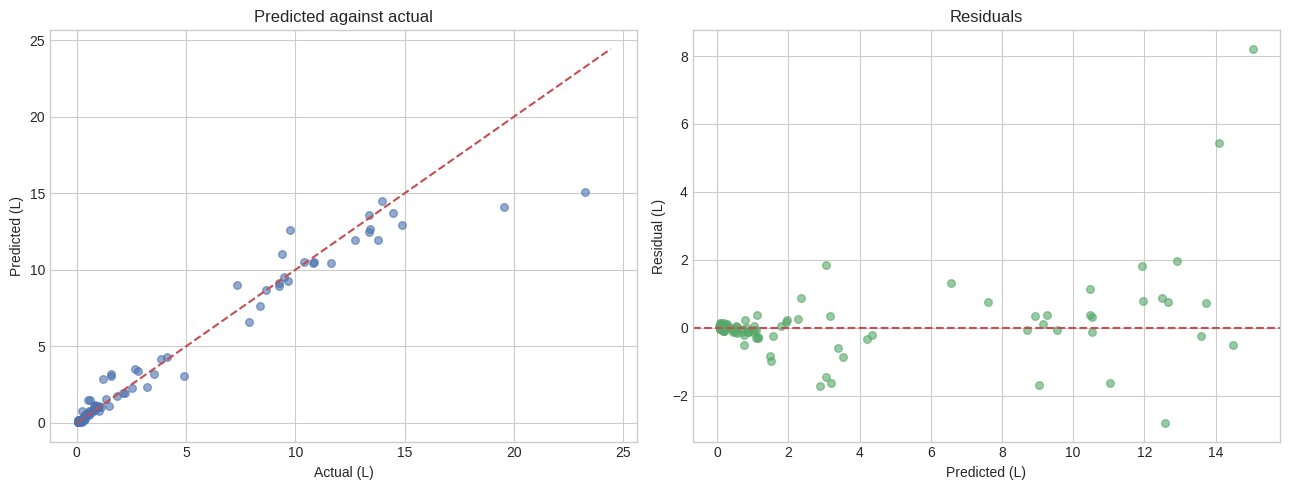

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_holdout, predictions, alpha=0.6, s=30, color="#4C72B0")
lims = [0, max(y_holdout.max(), predictions.max()) * 1.05]
axes[0].plot(lims, lims, "--", color="#C44E52", lw=1.5)
axes[0].set_xlabel("Actual (L)"); axes[0].set_ylabel("Predicted (L)")
axes[0].set_title("Predicted against actual")

residuals = y_holdout - predictions
axes[1].scatter(predictions, residuals, alpha=0.6, s=30, color="#55A868")
axes[1].axhline(0, ls="--", color="#C44E52", lw=1.5)
axes[1].set_xlabel("Predicted (L)"); axes[1].set_ylabel("Residual (L)")
axes[1].set_title("Residuals")

plt.tight_layout()
plt.savefig(f"{FIGURES}/holdout_performance.png", dpi=120, bbox_inches="tight")
plt.show()

Residual spread widens with predicted value, which is expected for a skewed
positive target. For anomaly detection that matters: a fixed litre threshold
would flag large jobs constantly and small ones never. A percentage-of-expected
threshold is the sensible operational rule.

## 6. What the model actually uses

Permutation importance on the holdout, which measures how much the error grows
when a single feature is shuffled.

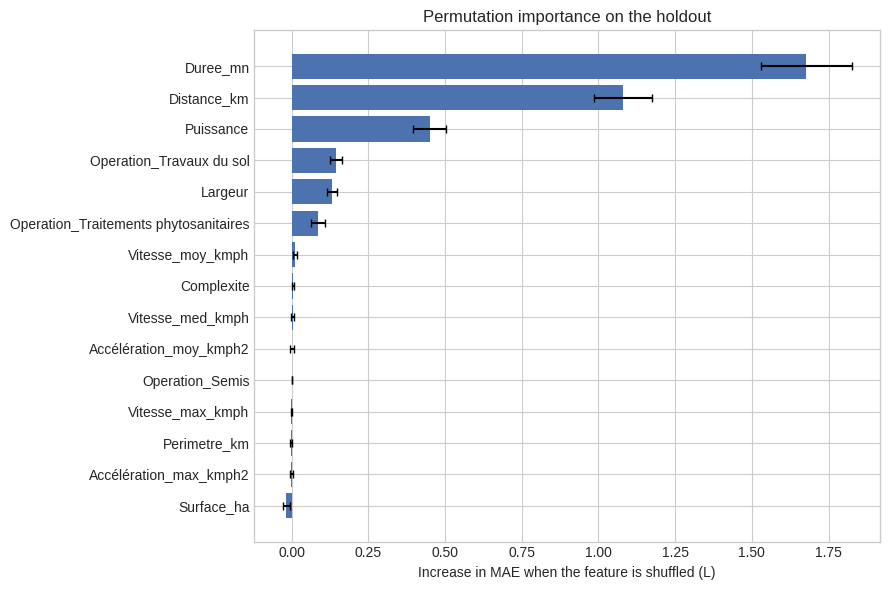

                              feature  importance      std
                             Duree_mn    1.677959 0.147094
                          Distance_km    1.079678 0.093596
                            Puissance    0.450077 0.053395
             Operation_Travaux du sol    0.144331 0.019269
                              Largeur    0.132197 0.015778
Operation_Traitements phytosanitaires    0.086249 0.022958


In [9]:
importance = permutation_importance(final_model, X_holdout, y_holdout,
                                    n_repeats=20, random_state=RANDOM_STATE,
                                    scoring="neg_mean_absolute_error")

ranked = (pd.DataFrame({"feature": X.columns,
                        "importance": importance.importances_mean,
                        "std": importance.importances_std})
          .sort_values("importance", ascending=True))

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(ranked["feature"], ranked["importance"], xerr=ranked["std"],
        color="#4C72B0", capsize=3)
ax.set_xlabel("Increase in MAE when the feature is shuffled (L)")
ax.set_title("Permutation importance on the holdout")
plt.tight_layout()
plt.savefig(f"{FIGURES}/feature_importance.png", dpi=120, bbox_inches="tight")
plt.show()

print(ranked.sort_values("importance", ascending=False).head(6).to_string(index=False))

## 7. Scoring the unlabelled test set

`interventions_test.csv` has no `Consommation` column, so it cannot be used to
measure accuracy — only to produce predictions. Trajectory features are
required, and this repository ships traces for 100 of the 320 test
interventions, so predictions are generated for that subset.

In [10]:
from data_processing import process_parcels, process_trajectories

test = pd.read_csv("../data/raw/interventions_test.csv")
test["ID"] = test["ID"].astype(str)

test_traj = process_trajectories("../data/raw/trajets_test")
test_traj["ID"] = test_traj["ID"].astype(str)
parcels = process_parcels("../data/raw/Parcelles")

test_full = test.merge(test_traj, on="ID", how="inner").merge(parcels, on="Parcelle", how="left")
for col in ["Surface_ha", "Perimetre_km", "Complexite"]:
    test_full[col] = test_full[col].fillna(df[col].median())

print(f"scoreable test interventions: {len(test_full)} / {len(test)}")

scoreable test interventions: 100 / 320


In [11]:
test_X = pd.get_dummies(test_full.drop(columns=DROP), columns=["Operation"], drop_first=True)
# Align to the training schema: unseen categories dropped, absent ones zero-filled.
test_X = test_X.reindex(columns=X.columns, fill_value=0)

output = pd.DataFrame({
    "ID": test_full["ID"],
    "Predicted_Consumption_L": final_model.predict(test_X).round(3),
})
output.to_csv(f"{PROCESSED}/predictions.csv", index=False)

print(output.head(10).to_string(index=False))
print(f"\n{len(output)} predictions written to data/processed/predictions.csv")

    ID  Predicted_Consumption_L
130066                    0.301
130063                    0.050
130024                    5.690
129931                    0.122
129785                    0.203
129536                    1.620
129343                    0.295
129219                    0.096
129206                    0.390
129020                    6.449

100 predictions written to data/processed/predictions.csv


## Summary and limitations

The final model is a `GradientBoostingRegressor` with scikit-learn defaults,
cross-validated against four baselines and scored once on a held-out fifth of
the data.

Known limitations:

- **No hyperparameter search.** Defaults beat hand-picked values here; a proper
  search would likely beat both.
- **500 training rows.** Small enough that the holdout estimate carries real
  uncertainty, which is why the cross-validated standard deviations are
  reported alongside every score.
- **Retrospective only.** Duration and distance are unavailable before a job
  runs, so this model cannot be used for forward fuel planning without a
  different feature set.
- **One missing parcel outline** affects 4 interventions, median-imputed.